## 📊 Motivation: The Correlation Between Credit Grade and LGD

In financial practice, while **Credit Ratings (Grade)** are the primary determinants of the **Probability of Default (PD)**, their correlation with **Loss Given Default (LGD)** remains a subject of ongoing debate.

---

### 🔍 Research Objective
It is a conventional assumption that higher-grade borrowers exhibit lower LGD due to better collateral or financial stability. However, this analysis utilizes public data from **Lending Club** to investigate a more nuanced hypothesis:

> **How do borrower attributes (Grade) bias the "economic rationality of recovery" post-default?**

### 💡 Key Focus Areas
We aim to highlight how the following factors influence the recovery process:

*   **Information Asymmetry:** Do higher-grade borrowers have more strategic options to manage default?
*   **Legal Resource Disparities:** How does the difference in access to legal/financial advice affect the final recovery rate?
*   **Systemic Bias:** Does the "Grade" itself influence the intensity or efficiency of the collection process?

---

<div style="padding: 15px; border: 1px solid #e1e4e8; border-radius: 6px; background-color: #f6f8fa;">
    <strong>Note:</strong> This study seeks to uncover whether the recovery process is purely driven by asset value, or if it is inherently biased by the borrower's socio-economic status as reflected in their credit grade.
</div>

In [1]:
#3.11.8
import mysql.connector
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
config = {
    'user': os.getenv('DB_USER'),
    'password': os.getenv('DB_PASSWORD'),
    'host': os.getenv('DB_HOST'),
    'database': os.getenv('DB_NAME'),
}

/var/folders/36/yf0pfpsd6yj43w2y6f0k80tm0000gn/T/ipykernel_1618/1891967795.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,grade,default_cases,EAD,total_recoveries,LGD
0,A,14206,1.150405e+08,11525466.45,89.98
1,B,52576,4.550484e+08,47306311.94,89.60
2,C,85657,8.833808e+08,94085003.79,89.35
3,D,61067,7.229832e+08,77989289.23,89.21
4,E,36041,5.116121e+08,57762377.24,88.71
5,F,14492,2.338299e+08,27067286.02,88.42
6,G,4560,8.021983e+07,9074807.88,88.69


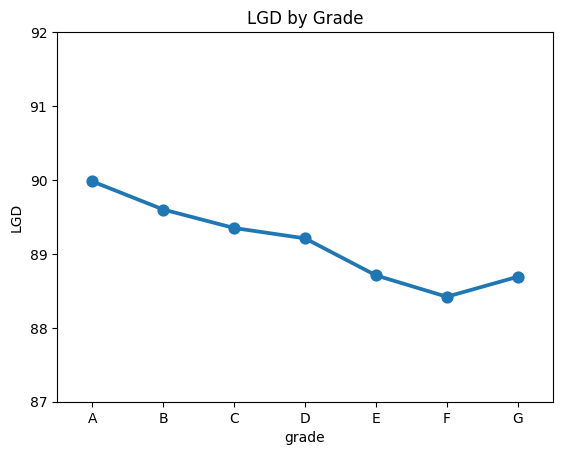

In [3]:
try:
    conn = mysql.connector.connect(**config)
    
    query = """
SELECT grade
       ,COUNT(id) AS default_cases
       ,SUM(loan_amnt - total_rec_prncp) AS EAD
       ,SUM(recoveries) AS total_recoveries
       ,ROUND((1 - SUM(recoveries) / NULLIF(SUM(loan_amnt - total_rec_prncp), 0)) * 100, 2) AS LGD
  FROM lending_loans
 WHERE loan_status IN ("Charged Off", "Default")
 GROUP BY grade
 ORDER BY grade
;
            """
    df = pd.read_sql(query, conn)

finally:
    if conn.is_connected():
        conn.close()

display(df)
print()
sns.pointplot(data = df, x = "grade", y = "LGD")
plt.ylim(87, 92)
plt.title("LGD by Grade")
plt.show()

## 📉 Initial Aggregate Analysis & Identified Anomalies

The initial analysis of the full dataset revealed **two distinct behaviors** that deviate from conventional credit risk theory:

*   **Abnormally High LGD:** Across all grades, the LGD consistently remains around 90%, indicating that recovery efforts are yielding minimal results.
*   **Inverse Correlation with Credit Grades:** Counter-intuitively, higher-grade loans (Grade A and B) exhibit a higher LGD than lower-grade loans, contradicting standard risk expectations.

---

## 💡 Hypothesis & Data Filtering Strategy

I hypothesize that these anomalies are driven by **"noise" from Active Loans** (loans still in the repayment process) within the dataset.

<div style="padding: 15px; border-left: 5px solid #2196F3; background-color: #f0f7ff; color: #000;">
To eliminate this bias, I will identify the period where the data has sufficiently matured by analyzing the ROI trends of the entire portfolio. The subsequent analysis will focus exclusively on this refined, matured subset to ensure a more accurate assessment of recovery performance.
</div>

/var/folders/36/yf0pfpsd6yj43w2y6f0k80tm0000gn/T/ipykernel_1618/3877759907.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df2 = pd.read_sql(query, conn)


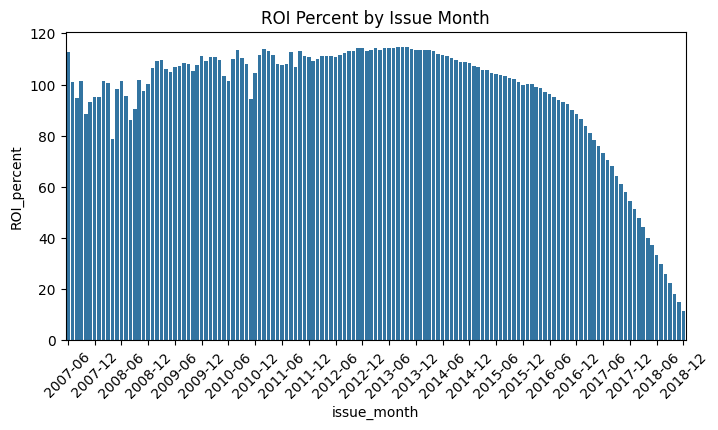

In [4]:
try:
    conn = mysql.connector.connect(**config)
    
    query = """
SELECT DATE_FORMAT(issue_d, '%Y-%m') AS issue_month
       ,SUM(loan_amnt) AS total_amnt
       ,SUM(total_pymnt) AS total_pymnt
       ,COUNT(id)
       ,ROUND((SUM(total_pymnt) / NULLIF(SUM(loan_amnt), 0)) * 100, 2) AS ROI_percent
  FROM lending_loans
 GROUP BY DATE_FORMAT(issue_d, '%Y-%m')
 ORDER BY issue_month
;
            """
    df2 = pd.read_sql(query, conn)
finally:
    if conn.is_connected():
        conn.close()
plt.figure(figsize = (8, 4))
ax =sns.barplot(data = df2, x = "issue_month", y = "ROI_percent")
ax.xaxis.set_major_locator(ticker.MultipleLocator(6))
plt.title("ROI Percent by Issue Month")
plt.xticks(rotation=45)
plt.show()

---

### 🔍 Maturity Analysis via ROI Trends

By analyzing the `ROI_percent` trends, I identified a specific point where the ratio begins a continuous decline and fails to exceed the **100% threshold**. 

This indicates that the loans issued after this period have not yet reached maturity. I will pinpoint this transition point using the data stored in `df2`.

<div style="margin-top: 10px; padding: 10px; border-radius: 4px; background-color: #fff3cd; border: 1px solid #ffeeba;">
    <strong>Action:</strong> Identifying the cutoff point to filter out immature Active Loans.
</div>

In [5]:
df2_ROI = df2[df2["ROI_percent"] > 100][["issue_month", "ROI_percent"]].sort_values(by="issue_month", ascending=False)
df2_ROI.head()

,issue_month,ROI_percent
105,2016-02,100.34
104,2016-01,100.22
102,2015-11,100.91
101,2015-10,102.31
100,2015-09,102.51


---

### 📌 Dataset Refinement & SQL Filtering

The results indicate that from **February 2016** onwards, the `ROI_percent` consistently remains below 100%. Consequently, to ensure data integrity and focus on matured loan portfolios, I will restrict the dataset to records issued prior to February 2016.

I will re-calculate the LGD for this refined period by applying the following filter in the SQL query:

```sql
WHERE DATE_FORMAT(issue_d, '%Y-%m') < '2016-02'

/var/folders/36/yf0pfpsd6yj43w2y6f0k80tm0000gn/T/ipykernel_1618/1666105930.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df3= pd.read_sql(query, conn)


,grade,default_cases,EAD,total_recoveries,LGD
0,A,8502,5.923203e+07,7359132.51,87.58
1,B,30156,2.353325e+08,28644854.36,87.83
2,C,47538,4.403645e+08,54046033.51,87.73
3,D,36500,4.007048e+08,49248592.98,87.71
4,E,23593,3.224292e+08,39807073.56,87.65
5,F,9112,1.415736e+08,17987912.76,87.29
6,G,2365,3.985319e+07,5063221.12,87.30


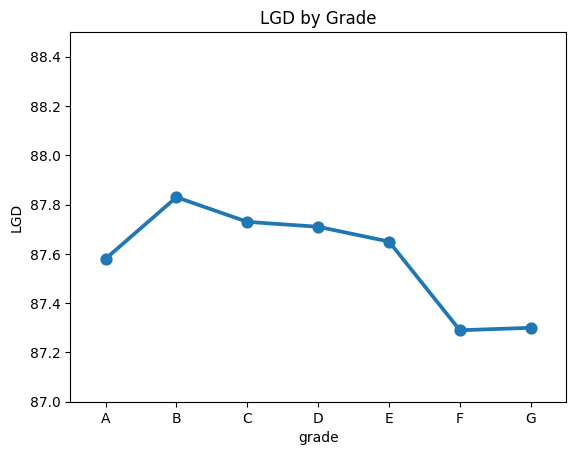

In [6]:
try:
    conn = mysql.connector.connect(**config)
    
    query = """
WITH Step1 AS (
    SELECT grade
           ,id
           ,loan_amnt - total_rec_prncp AS user_EAD
           ,recoveries
      FROM lending_loans
     WHERE loan_status IN ("Charged Off", "Default")
       AND DATE_FORMAT(issue_d, "%Y-%m") < '2016-02'
)

SELECT grade
       ,COUNT(id) AS default_cases
       ,SUM(user_EAD) AS EAD
       ,SUM(recoveries) AS total_recoveries
       ,ROUND((1 - SUM(recoveries) / NULLIF(SUM(user_EAD), 0)) * 100, 2) AS LGD
  FROM Step1
 GROUP BY grade
 ORDER BY grade
;
            """
    df3= pd.read_sql(query, conn)

finally:
    if conn.is_connected():
        conn.close()

display(df3)
print()

sns.pointplot(data = df3, x = "grade", y = "LGD")
plt.ylim(87, 88.5)
plt.title("LGD by Grade")

plt.show()

---

## 🧐 Observed Anomalies and Data Validation

The data refinement successfully improved the LGD figures, and the relationship between Credit Grades and loss rates has stabilized, confirming the validity of the selected timeframe. However, a significant paradox remains:

> **Lower-grade loans consistently exhibit a lower LGD than higher-grade loans.**

While fluctuations in loan amounts and payment histories can inflate the **Exposure at Default (EAD)**, the substantial sample size within `default_cases` suggests that this inverse correlation is a **statistically significant trend** rather than a calculation error.

---

## 💡 Hypothesis: The "Recovery Bias" of High-Attribute Borrowers

Standard theory suggests that high-grade borrowers, with higher repayment capacities, should have lower EAD $$EAD = \sum (\mathrm{loan\_amnt} - \mathrm{total\_rec\_prncp})$$. Why, then, is their LGD disproportionately high?

I propose the **"Debtor's Recovery Bias"** hypothesis:

*   **Strategic Default and Legal Literacy**: High-grade borrowers are not only financially capable but often possess superior financial literacy and access to legal resources. When facing insolvency, they may act more "rationally" by prioritizing which debts to honor and which to legally block. In the context of unsecured P2P lending, these borrowers might proactively initiate bankruptcy proceedings or utilize legal protections to strategically "exit" the debt.
*   **Passive Recovery in Lower Grades**: In contrast, lower-grade borrowers may be more passive in the face of collection pressures. This results in a structural difference where small, fragmented recoveries continue over time for lower-grade loans, whereas high-grade recoveries are more likely to be completely cut off by legal maneuvers.

---

## 🚀 Next Step: Bifurcation Analysis

To test this hypothesis, I will conduct a **bifurcated analysis** separating the:
1.  **"Non-Recovery Rate"** (cases with zero recovery)
2.  **"Conditional LGD"** (LGD for cases where at least some recovery occurred)

This will help determine if the high LGD in top-tier grades is driven by a higher frequency of **"complete recovery failure."**

Before analyzing non-recovery rates, I examined the Average EAD Percentage (<code>avg_EAD_percent</code>)—the ratio of the remaining principal to the original loan amount at the time of default—across different grades. The results revealed a distinct trend.

/var/folders/36/yf0pfpsd6yj43w2y6f0k80tm0000gn/T/ipykernel_1618/438794252.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df4 = pd.read_sql(query, conn)


,grade,avg_EAD,avg_loan_amnt,avg_EAD_percent
0,A,6966.834515,13496.339097,51.62
1,B,7803.836596,13524.393985,57.70
2,C,9263.419853,14497.997392,63.89
3,D,10978.213925,15852.291096,69.25
4,E,13666.307504,18295.576018,74.70
5,F,15537.049817,19638.221576,79.12
6,G,16851.245226,20652.114165,81.60


<Axes: xlabel='grade', ylabel='avg_EAD_percent'>

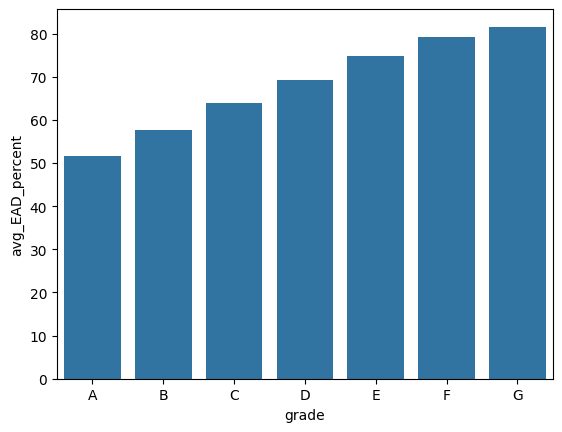

In [7]:
try:
    conn = mysql.connector.connect(**config)
    
    query = """
SELECT grade
       ,AVG(loan_amnt - total_rec_prncp) AS avg_EAD
       ,AVG(loan_amnt) AS avg_loan_amnt
       ,ROUND(AVG(loan_amnt - total_rec_prncp) / AVG(loan_amnt) * 100, 2) AS avg_EAD_percent
  FROM lending_loans
 WHERE DATE_FORMAT(issue_d, '%Y-%m') < '2016-02'
   AND loan_status IN ("Charged Off", "Default")
 GROUP BY grade
 ORDER BY grade
;
            """
    df4 = pd.read_sql(query, conn)

finally:
    if conn.is_connected():
        conn.close()

display(df4)
print()
sns.barplot(data = df4, x = "grade", y = "avg_EAD_percent")

---

## 📊 Key Findings: Principal Balance at Default

The analysis reveals a stark contrast in repayment behavior prior to default:

*   **Grade A:** The outstanding principal at default is approximately **51.6%**.
*   **Grade G:** The outstanding principal at default is approximately **81.6%**.
*   **The Gap:** A significant discrepancy of **30 percentage points** exists between high-grade and low-grade borrowers.

---

## 💡 Implications

These results confirm that **higher-grade borrowers have repaid a significantly larger portion of their principal** before reaching a state of default.

Despite this "head start" in repayment, the earlier finding that high-grade loans still result in a higher LGD is critical. It reinforces the following conclusions:

1.  **Sudden Cessation of Recovery:** A complete stop in recovery occurs specifically within the high-attribute segment once the default process begins.
2.  **LGD Drivers:** The recovery process post-default—rather than the balance at the time of default—is the primary driver of high LGD for top-tier borrowers.

<div style="padding: 15px; border: 1px solid #d1d5da; border-radius: 6px; background-color: #f6f8fa; color: #24292e;">
    <strong>Strategic Insight:</strong> For top-tier borrowers, risk management should focus not just on the <em>likelihood</em> of default, but on the <em>legal and strategic barriers</em> to recovery that emerge immediately after the default event.
</div>

/var/folders/36/yf0pfpsd6yj43w2y6f0k80tm0000gn/T/ipykernel_1618/110194843.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df5 = pd.read_sql(query, conn)


,grade,COUNT(id),non_recoveries_cases,non_recoveries_rate,conditional_LGD
0,A,8502,2533.0,29.79,82.40
1,B,30156,7470.0,24.77,84.01
2,C,47538,10804.0,22.73,84.38
3,D,36500,8295.0,22.73,84.38
4,E,23593,5520.0,23.40,84.30
5,F,9112,1982.0,21.75,84.19
6,G,2365,473.0,20.00,84.47


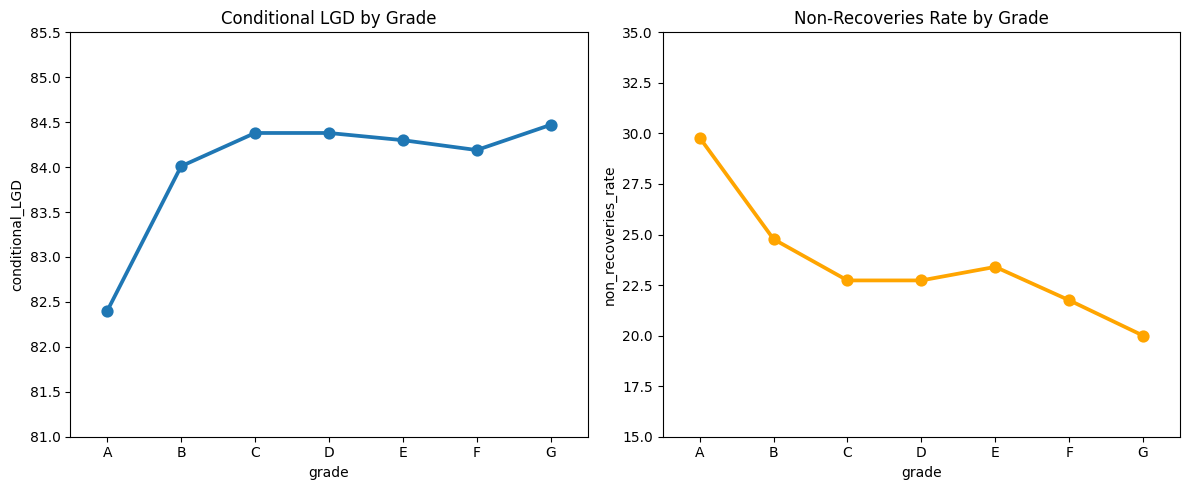

In [8]:
try:
    conn = mysql.connector.connect(**config)
    
    query = """
SELECT grade
       ,COUNT(id)
       ,SUM(CASE WHEN recoveries = 0 THEN 1 ELSE 0 END) AS non_recoveries_cases
       ,ROUND(SUM(CASE WHEN recoveries = 0 THEN 1 ELSE 0 END) / COUNT(id) * 100, 2) AS non_recoveries_rate
       ,ROUND(
            (1 - (SUM(CASE WHEN recoveries > 0 THEN recoveries ELSE 0 END) 
               / NULLIF(SUM(CASE WHEN recoveries > 0 THEN (loan_amnt - total_rec_prncp) ELSE 0 END), 0)
            )) * 100, 2) AS conditional_LGD
  FROM lending_loans
 WHERE loan_status IN ("Charged Off", "Default")
   AND DATE_FORMAT(issue_d, '%Y-%m') < '2016-02'
 GROUP BY grade
 ORDER BY grade
 ;
            """
    df5 = pd.read_sql(query, conn)

finally:
    if conn.is_connected():
        conn.close()

display(df5)
print()
fig, ax = plt.subplots(1, 2, figsize = (12, 5))
sns.pointplot(data = df5, x = "grade", y = "conditional_LGD", ax = ax[0])
ax[0].set_ylim(81, 85.5)
ax[0].set_title("Conditional LGD by Grade")

sns.pointplot(data = df5, x = "grade", y = "non_recoveries_rate", ax = ax[1], color = "orange")
ax[1].set_ylim(15, 35)
ax[1].set_title("Non-Recoveries Rate by Grade")

plt.tight_layout()
plt.show()

---

## 🏁 Conclusion: Strategic Defaults and Tail Risks Hidden Behind LGD Averaging

Through this analysis, it has become clear that the seemingly uniform LGD across credit grades is actually the result of **two opposing dynamics**: **recoverability** and **recovery efficiency**.

### 1. High-Attribute Borrowers: Strategic Default and Total Loss Risk
*   **Characteristics:** While these borrowers exhibit a lower *Conditional LGD* (loss rate when recovery efforts are successful), they show a significantly higher **Non-Recovery Rate** (probability of zero recovery).
*   **Mechanism:** High-grade borrowers may intuitively grasp the "break-even point of recovery costs." When the EAD is low, the cost-effectiveness of legal action diminishes for the creditor. At this stage, these borrowers appear to opt for **"Strategic Default"** based on economic rationality—utilizing legal means such as personal bankruptcy to completely sever debt obligations.
*   **Implication:** The assumption that "Grade A is safe" carries the danger of **overlooking Tail Risk**. While the probability of default is lower, the impact of a default event is more likely to result in a **total loss**.

### 2. Low-Attribute Borrowers: Passive Default and Sustained Recovery
*   **Characteristics:** Although default frequency is higher, the **Non-Recovery Rate is lower** compared to high-attribute segments.
*   **Mechanism:** Borrowers with limited legal resources tend to be more passive toward collection efforts or wage garnishments. Consequently, the recovery process—though consisting of small, fragmented payments—is more likely to persist over the long term, effectively averting a **"total loss" scenario**.

---

<div style="padding: 20px; border-radius: 10px; background: linear-gradient(135deg, #2c3e50, #4ca1af); color: white;">
    <h4 style="margin-top: 0; color: #ffffff;">📌 Final Synthesis</h4>
    <p style="margin-bottom: 0;">
        Standard credit scoring models often underestimate the <strong>binary nature of recovery in high-grade segments</strong>. This analysis suggests that for high-attribute portfolios, LGD estimation requires a model that accounts for the <strong>strategic behavior of debtors</strong> and the <strong>economic thresholds of collection costs</strong>, rather than relying on simple grade-based averages.
    </p>
</div>